In [17]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design


In [18]:
import numpy as np
import random
import os

from ribs.archives import ProximityArchive
from ribs.schedulers import Scheduler

from emitter import CustomEmitter
from mapelite.qd_runner import setup_dask, resume_from_checkpoint, run_qd_loop, plot_stats, export_elites

In [19]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    CHECKPOINT_DIR,
    STATS_DIR,
    INVALID_SCORE,
    ITERATIONS
)

# --- Novelty Search specific config ---
stats_dir = STATS_DIR
checkpoint_dir = CHECKPOINT_DIR + "ns/"
EMBEDDING_DIM = 32
DEFAULT_THRESHOLD = 5
SEED = 67
STATS_FILENAME = "ns_stats.pkl"
ELITES_OUTPUT = "data/elites/ns.json"
ALGORITHM_LABEL = "Novelty Search (ProximityArchive + local competition)"

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

In [20]:
# --- Initialize directories ---
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(stats_dir, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = setup_dask(BATCH_SIZE)

Setting up Dask LocalCluster...


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 56079 instead
  warnings.warn(
C:\Users\milob\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.04s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Dask Dashboard link: http://127.0.0.1:56079/status
Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_latent32.pth...
Model loaded with latent_dim=32
Evaluator scattered to 10 Dask workers


In [21]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise build archive from scratch
# --------------------------------------------------------------
state = resume_from_checkpoint(checkpoint_dir, stats_dir, STATS_FILENAME)
start_iter        = state["start_iter"]
global_best_score = state["global_best_score"]
global_best_id    = state["global_best_id"]
stats             = state["stats"]

if state["scheduler"] is not None:
    scheduler = state["scheduler"]
    archive   = state["archive"]
else:
    archive = ProximityArchive(
        solution_dim=SOLUTION_DIM,
        measure_dim=EMBEDDING_DIM,
        k_neighbors=15,
        novelty_threshold=DEFAULT_THRESHOLD,
        seed=SEED,
        local_competition=True
    )

    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))]
    )

    scheduler = Scheduler(archive, [emitter])

[Resume] Loaded data/checkpoints/ns\checkpoint_1000.pkl, resuming from iteration 1001
[Resume] Resumed stats with 1000 entries


In [22]:
# print ribs version
import ribs
print(f"Ribs version: {ribs.__version__}")

Ribs version: 0.9.0


In [23]:
# # --- Pilot: measure pairwise distances in embedding space ---
# from scipy.spatial.distance import pdist

# PILOT_ITERS = 5  # number of batches to sample
# pilot_measures = []

# for _ in range(PILOT_ITERS):
#     sols = scheduler.ask()
#     sol_dicts = [array_to_solution(sol) for sol in sols]

#     futs = [client.submit(_eval_on_worker, evaluator_future, sol) for sol in sol_dicts]
#     gathered = [f.result() for f in as_completed(futs)]

#     for sol_id, ok, msg, score, desc in gathered:
#         if ok:
#             pilot_measures.append(desc)

#     # Still need to tell the scheduler so it doesn't break
#     objs, descs = zip(*[(score if ok else INVALID_SCORE, desc)
#                         for sol_id, ok, msg, score, desc in gathered])
#     scheduler.tell(list(objs), list(descs))

# pilot_measures = np.array(pilot_measures)
# dists = pdist(pilot_measures)

# print(f"Pilot: {len(pilot_measures)} valid embeddings collected")
# print(f"Pairwise distances — min={dists.min():.4f}, "
#       f"25th={np.percentile(dists, 25):.4f}, "
#       f"median={np.median(dists):.4f}, "
#       f"75th={np.percentile(dists, 75):.4f}, "
#       f"max={dists.max():.4f}, "
#       f"mean={dists.mean():.4f}")
# print(f"\nSuggested novelty_threshold range: {np.percentile(dists, 10):.4f} – {np.median(dists) * 0.5:.4f}")

In [24]:
# Run main loop
global_best_score, global_best_id, stats = run_qd_loop(
    scheduler=scheduler,
    archive=archive,
    client=client,
    evaluator_future=evaluator_future,
    total_iters=ITERATIONS,
    start_iter=start_iter,
    checkpoint_dir=checkpoint_dir,
    stats_dir=stats_dir,
    stats_filename=STATS_FILENAME,
    stats=stats,
    global_best_score=global_best_score,
    global_best_id=global_best_id,
)

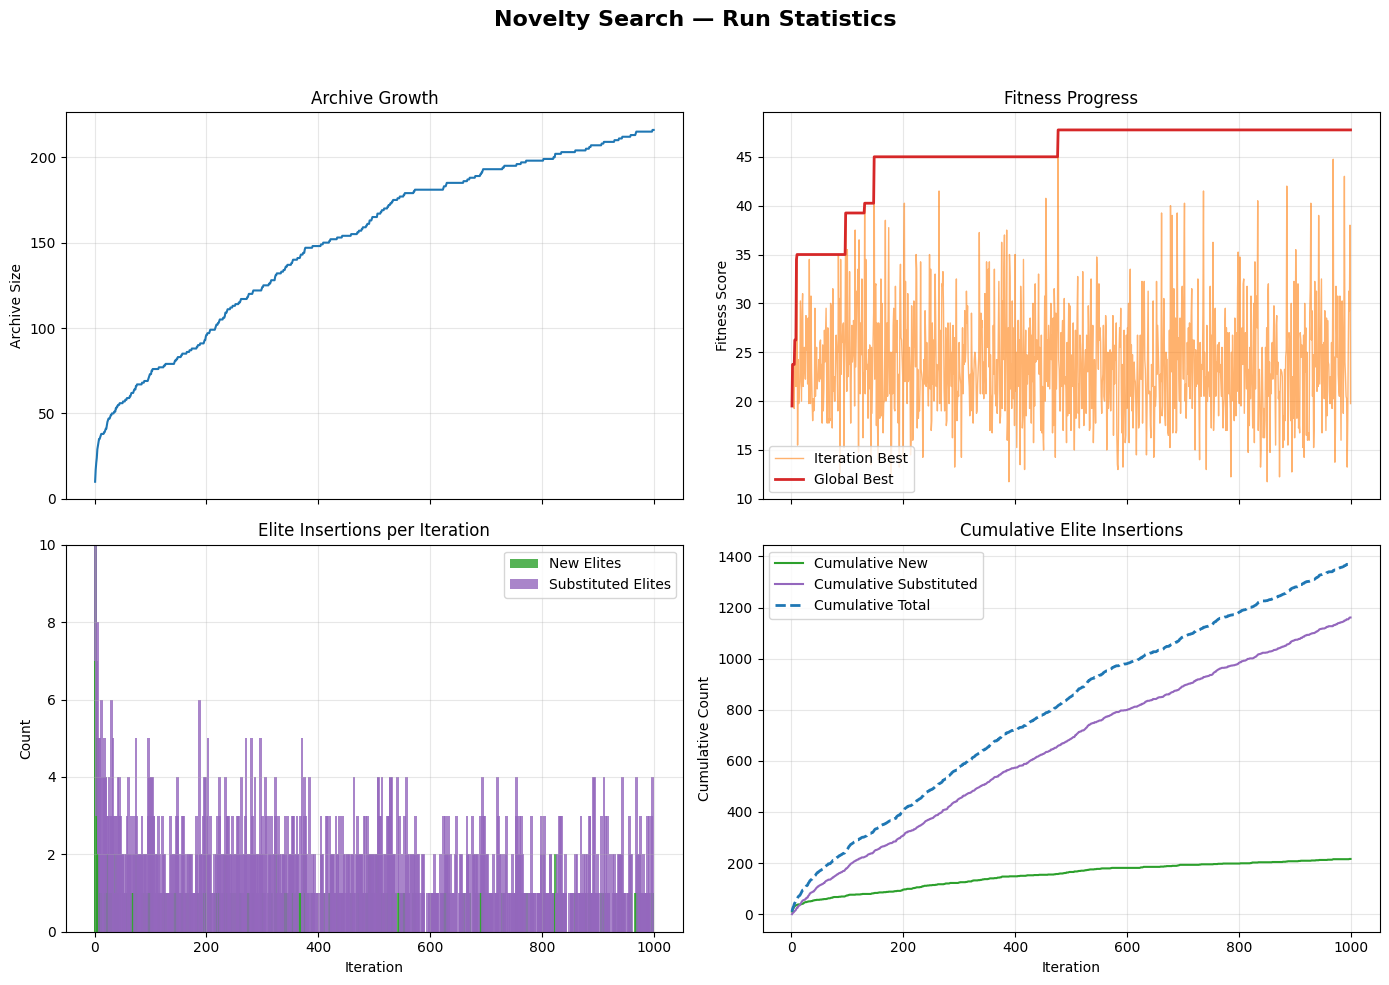


  Novelty Search Summary
  Total iterations:        1000
  Final archive size:      216
  Global best fitness:     47.7500
  Total new elites:        216
  Total substituted:       1161
  Avg new elites/iter:     0.22
  Avg substituted/iter:    1.16


In [25]:
plot_stats(stats, title="Novelty Search")

In [26]:
export_elites(
    archive=archive,
    stats=stats,
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED,
    global_best_score=global_best_score,
    global_best_id=global_best_id,
)

AttributeError: 'ArrayStore' object has no attribute '_xp'